
**Lorenz–96 model and green function computation for two variables**

We consider the Lorenz–96 dynamical system for x and $\theta$:
$$
    dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - \alpha \theta_i - \gamma x_i + F
$$
$$
    d\theta_i/dt = x_{i+1} * \theta_{i+2} - x_{i-1} * \theta_{i-2} +\alpha x_i - \gamma \theta_i + G
$$
with cyclic indices:
$$
x_{i-N} = x_{i+N} = x_i 
$$
$$
\theta_{i-N} = \theta_{i+N} = \theta_i
$$

Parameters:
-  N : number of variables (typically 40)
-  F, G : constant forcing (typically F = 8 for chaotic regime)
-  $\alpha, \gamma$: perturbation

Considering $\gamma = \alpha = 1$, the **unperturbed system** is written as:
$$
\dot{x}_i = F_i(x)
$$
$$
\dot{\theta}_i = G_i(\theta)
$$

For Lorenz–96:

$$
F_i(x) = (x_{i+1} - x_{i-2}) * x_{i-1} - \theta_i - x_i + F
$$
$$
G_i(\theta) =  x_{i+1} * \theta_{i+2} - x_{i-1} * \theta_{i-2} + x_i - \theta_i + G
$$
The **perturbed system** is written as:
- Adding perturbation to F:
    $$
    \dot{x}_i = F_i(x) + \epsilon X_i(x) f(t)
    $$
   
- Adding perturbation to $\gamma$:
    $$
    \dot{x}_i = F_i(x) - \epsilon \gamma X_i(x)
    $$
    $$
    \dot{\theta}_i = G_i(x) - \epsilon \gamma \theta_i(x)
    $$
- Adding perturbation to $\alpha$:
    $$
    \dot{x}_i = F_i(x) - \epsilon \alpha \theta_i(x)
    $$
    $$
    \dot{\theta}_i = G_i(x) + \epsilon \alpha X_i(x)
    $$

Note: In the followwing cells, we have replaced $\theta$ with z due to the use of simpler notation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Lorenz-96 UNPERTURBED dynamics
def lorenz96(t, state, F, G):
    
    N = len(state) // 2

    x = state[:N]
    z = state[N:]

    dxdt = np.zeros(N)
    dzdt = np.zeros(N)

    
    for i in range(N):
        dxdt[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] - z[i] + F
        dzdt[i] = x[(i+1)%N] * z[(i+2)%N] - x[(i-1)%N] * z[(i-2)%N] +x[i] - z[i] + G
    
    return np.concatenate([dxdt, dzdt])
    
# Setting the initial conditions
def standard_initial_condition(F,G,N):
    x = F * np.ones(N)
    z = G * np.ones(N)
    x[0] += 0.01  # small perturbation
    z[0] += 0.01
    return x,z

In [16]:
#Parameters:
dt = 0.005; 
T = 20000 ; 
N = 40 ; 
F = 8;
G = 8;
t_span = (0, T)
t_eval = np.arange(0, T, dt)
x0, z0 = standard_initial_condition(F, G, N)
state0 = np.concatenate([x0, z0])

In [17]:
#Running unperturbed trajectory
solution = solve_ivp(
    fun=lambda t, state: lorenz96(t, state, F, G),
    t_span=t_span,
    y0=state0,    
    t_eval=t_eval, 
    method='RK45'
)

traj = solution.y.T   # shape: (time, N)
time = solution.t

x_traj = traj[:, :N]
z_traj = traj[:, N:]

print(x_traj.shape)
print(z_traj.shape)

(4000000, 40)
(4000000, 40)


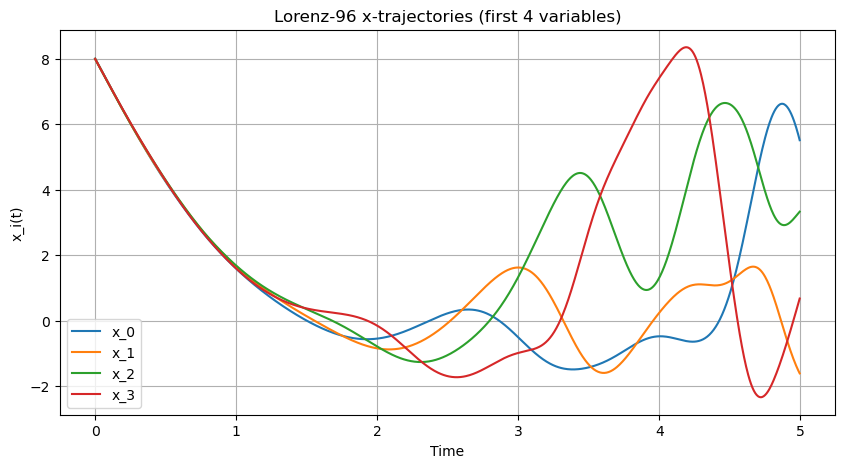

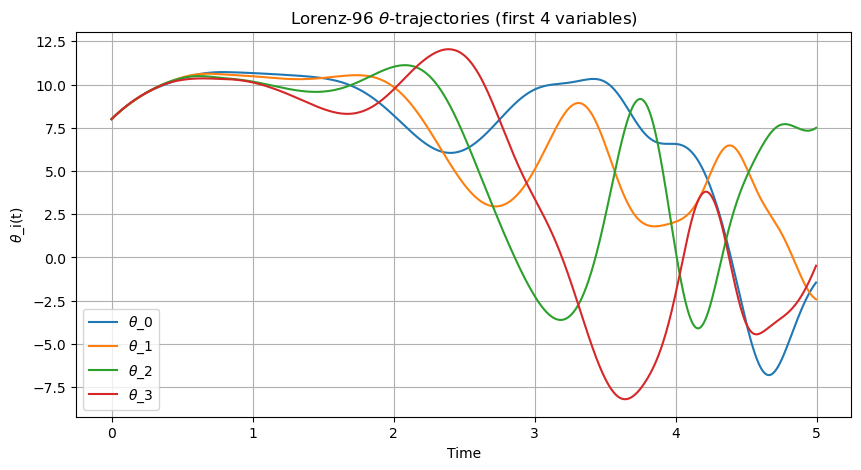

In [18]:
plt.figure(figsize=(10,5))

# plot the trajectories for first 4 variables
tau_plot = 1000
for i in range(4):
    plt.plot(time[:tau_plot], traj[:tau_plot, i], label=f"x_{i}")

plt.xlabel("Time")
plt.ylabel("x_i(t)")
plt.title("Lorenz-96 x-trajectories (first 4 variables)")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(10,5))

tau_plot = 1000

# Plot first 4 z variables
for i in range(4):
    plt.plot(time[:tau_plot], z_traj[:tau_plot, i], label=f"$\\theta$_{i}")

plt.xlabel("Time")
plt.ylabel("$\\theta$_i(t)")
plt.title("Lorenz-96 $\\theta$-trajectories (first 4 variables)")
plt.legend()
plt.grid()

plt.show()

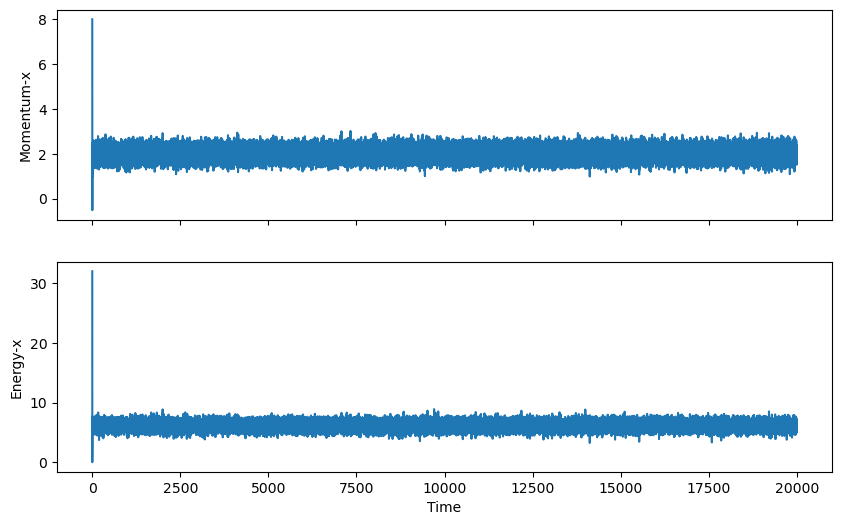

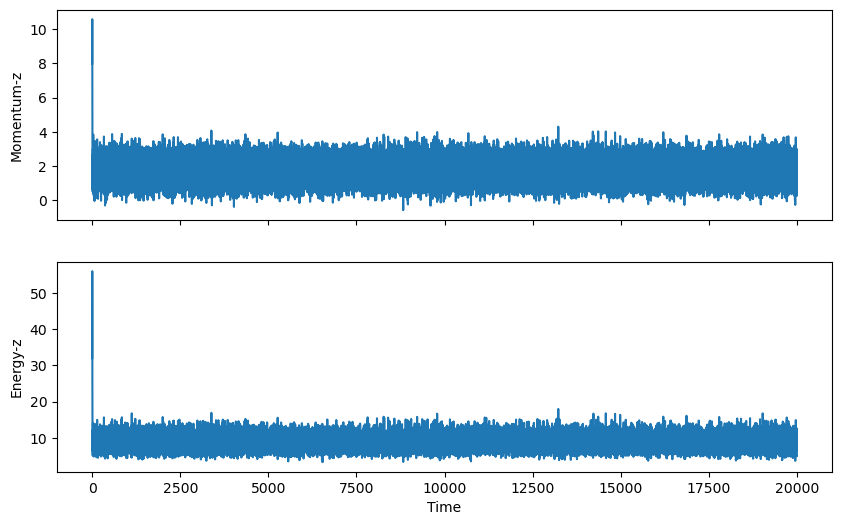

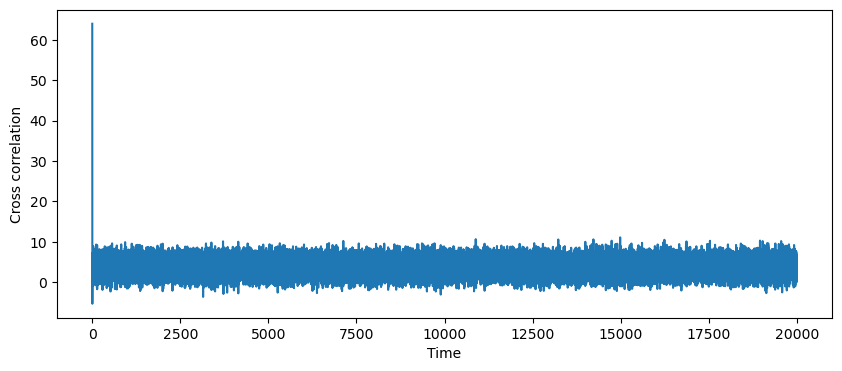

In [19]:
# Global observables for variables
momentum_x = x_traj.mean(axis=1)
energy_x = 0.5 * (x_traj**2).mean(axis=1)

momentum_z = z_traj.mean(axis=1)
energy_z = 0.5 * (z_traj**2).mean(axis=1)

cross_corr = (x_traj * z_traj).mean(axis=1) 

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10,6))

ax[0].plot(time, momentum_x)
ax[0].set_ylabel("Momentum-x")

ax[1].plot(time, energy_x)
ax[1].set_ylabel("Energy-x")
ax[1].set_xlabel("Time")

plt.show()

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10,6))

ax[0].plot(time, momentum_z)
ax[0].set_ylabel("Momentum-z")

ax[1].plot(time, energy_z)
ax[1].set_ylabel("Energy-z")
ax[1].set_xlabel("Time")
plt.show()


fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(time, cross_corr)
ax.set_ylabel("Cross correlation")
ax.set_xlabel("Time")

plt.show()


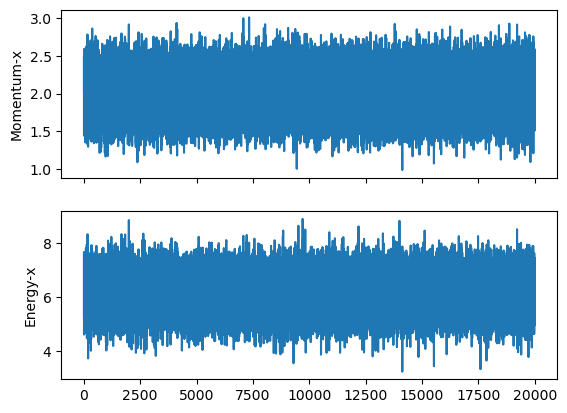

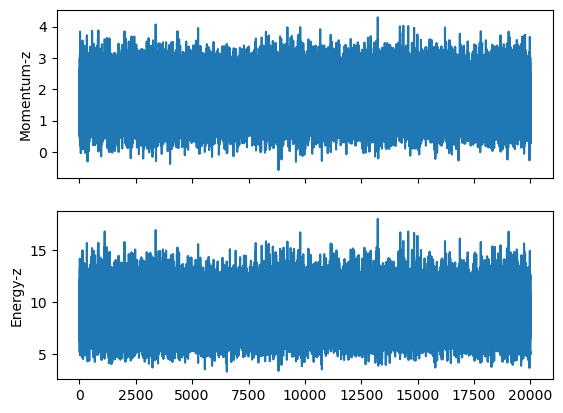

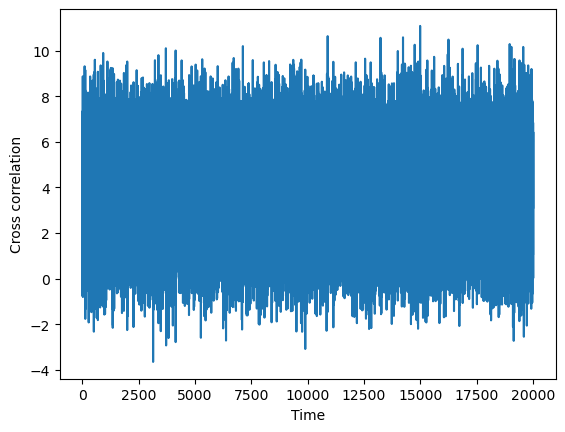

In [20]:
### Select the system when it has relaxed to the attractor (stationary state)
transient = 8
indx = np.where(time > transient)[0][0]

asymp_time = time[indx:]
asymp_traj_x = x_traj[indx:,:]
asymp_traj_z = z_traj[indx:,:]

# Global observables
asymp_momentum_x = asymp_traj_x.mean(axis=1)
asymp_momentum_z = asymp_traj_z.mean(axis=1)

asymp_energy_x = 0.5 *(asymp_traj_x**2).mean(axis=1)
asymp_energy_z = 0.5 *(asymp_traj_z**2).mean(axis=1)

asymp_cross_corr = (asymp_traj_x * asymp_traj_z).mean(axis=1)

fig , ax = plt.subplots(nrows=2,sharex=True)
ax[0].plot(asymp_time,asymp_momentum_x)
ax[0].set_ylabel("Momentum-x")

ax[1].plot(asymp_time,asymp_energy_x)
ax[1].set_ylabel("Energy-x")

fig , ax = plt.subplots(nrows=2,sharex=True)
ax[0].plot(asymp_time,asymp_momentum_z)
ax[0].set_ylabel("Momentum-z")

ax[1].plot(asymp_time,asymp_energy_z)
ax[1].set_ylabel("Energy-z")

# Cross-correlation
fig, ax = plt.subplots()

ax.plot(asymp_time, asymp_cross_corr)
ax.set_ylabel("Cross correlation")
ax.set_xlabel("Time")

plt.show()

In [21]:
# ### Correlation function analysis
# # 1. The system has to be on the attractor (asymptotic state)


def autocorrelation_fft(phi):
    phi = phi - np.mean(phi)
    N = len(phi)

    # Zero-padding to avoid circular correlation
    nfft = 2 * N

    F = np.fft.fft(phi, n=nfft)
    corr = np.fft.ifft(F * np.conjugate(F)).real[:N]

    return corr / corr[0]

corr_momentum_x = autocorrelation_fft(asymp_momentum_x)
corr_momentum_z = autocorrelation_fft(asymp_momentum_z)

corr_energy_x = autocorrelation_fft(asymp_energy_x)
corr_energy_z = autocorrelation_fft(asymp_energy_z)

corr_cross_corr = autocorrelation_fft(asymp_cross_corr)

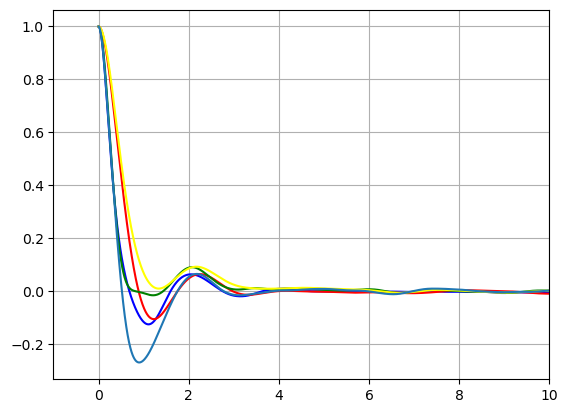

In [22]:
fig, ax = plt.subplots()
lags = np.arange(len(corr_momentum_x)) * dt
lags = np.arange(len(corr_momentum_z)) * dt
lags = np.arange(len(corr_cross_corr)) * dt

ax.plot(lags[:5000],corr_momentum_x[:5000], color = 'blue')
ax.plot(lags[:5000],corr_energy_x[:5000], color = 'red')
ax.plot(lags[:5000],corr_momentum_z[:5000], color = 'green')
ax.plot(lags[:5000],corr_energy_z[:5000], color = 'yellow')
ax.plot(lags[:5000], corr_cross_corr[:5000], label='Cross correlation')
ax.set_xlim(left=-1,right=10)
ax.grid()

### Response Properties:
1. Sample unperturbed states **&#10003;Done**
2. Use those as initial conditions for your response experiments **&#10003;Done**
3. When we integrate for a long time, we are trying to remove the transient so that the trajectory is sampling the invariant measure.

In [23]:
# Figuring out the initial conditions: states of the system separated at least by one correlation timescale
correlation_timescale = 2
correlation_timescale_index = int( correlation_timescale / dt )

unperturbed_sample_x = (asymp_traj_x[::correlation_timescale_index,:] )
unperturbed_sample_z = (asymp_traj_z[::correlation_timescale_index,:] )

In [24]:
print(unperturbed_sample_x.shape)

(9996, 40)


We have found the unperturbed $ \{ (x_i, z_i)\}_{i=1}^M $. Now let's proceed with the perturbation:

- Fix $x_1$, perturb

$\hat{x}_1 = x_1 + \varepsilon X(x_1)$

For example, change in F, this corresponds to X(x) = (0,0, ...,0, 1,0,0,...,0)

Given $\hat{x}_1$, we use it as initial condition for an **unperturbed** run.

In [50]:
eps = 1
M = len(unperturbed_sample_x) 
kick_index = 12

T_resp = 100
dt_resp = 0.05
t_resp =np.arange(0, T_resp, dt_resp)

def local_F_perturbation(x,kick_index,eps):
    y = np.copy(x)
    y[kick_index-1] = y[kick_index-1] + eps
    return y
    
def local_F_perturbation_minus(x,kick_index,eps):
    y = np.copy(x)
    y[kick_index-1] = y[kick_index-1] - eps
    return y


In [51]:
print(M)

9996


In [52]:
response = 0 
response_m = 0 

for i in range(M):
    # Local perturbation: we perturb x in location "kick_index"
    xi_hat = local_F_perturbation(unperturbed_sample_x[i,:],kick_index,eps)
    zi_hat = unperturbed_sample_z[i,:].copy()
    
    xi_hat_m = local_F_perturbation_minus(unperturbed_sample_x[i,:],kick_index,eps)

    # Initiate the relaxation run
    state_hat = np.concatenate([xi_hat,zi_hat])
    state_hat_m = np.concatenate([xi_hat_m,zi_hat])

    solution = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, T_resp),
        y0=state_hat,
        t_eval=t_resp,
        method='RK45'  
    )
    solution_m = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, T_resp),
        y0=state_hat_m,
        t_eval=t_resp,
        method='RK45'
    )
    
    # Define the observable and take averages: here we choose the full state
    Phi = solution.y
    Phi_m = solution_m.y

    # we are approximating integrals with respect to the invariant measure.
    response += Phi / M
    response_m += Phi_m / M

    # if(np.mod(i,50)==0):
        # print(i/M)
    
    

### response.shape
# response_m.shape

In [53]:
unperturbed_values_x = asymp_traj_x.mean(axis=0)
unperturbed_values_z = asymp_traj_z.mean(axis=0)

unperturbed_values = np.concatenate([unperturbed_values_x,unperturbed_values_z])

green_function = (response - response_m )/ (2 * eps)

[]

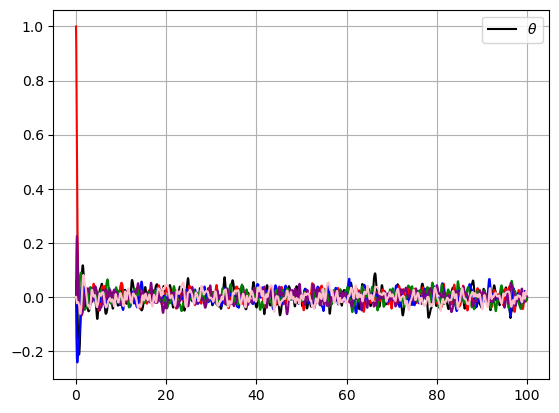

In [54]:
fig , ax = plt.subplots()

# ax.plot(t_resp,response[kick_index-1,:],label="x, where kicked")
# ax.plot(t_resp,response[kick_index-1+1+N,:],label="theta, where kicked")
ax.plot(t_resp,green_function[kick_index-1+N,:],label="$\\theta$", color = "black")



ax.plot(t_resp,green_function[kick_index-1,:], color="red")
ax.plot(t_resp,green_function[kick_index+1,:], color="blue")
ax.plot(t_resp,green_function[kick_index+2,:], color="green")
ax.plot(t_resp,green_function[kick_index-2,:], color="purple")
ax.plot(t_resp,green_function[kick_index,:], color="pink")

ax.legend()
ax.grid()

ax.plot()

[]

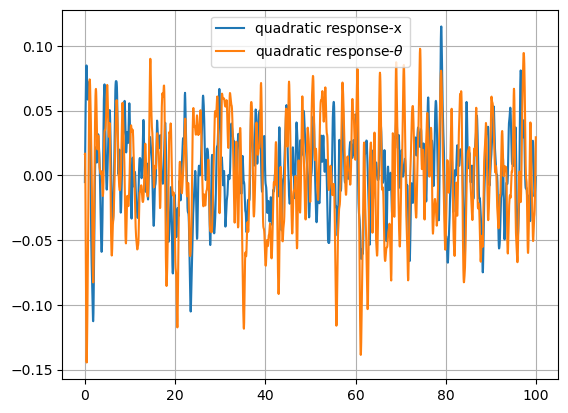

In [55]:
phi_mean_0 = np.mean(unperturbed_values_x)       # ⟨Φ⟩₀
phi_mean_0_z = np.mean(unperturbed_values_z)

fig , ax = plt.subplots()
ax.plot(t_resp,response[kick_index+2,:]- phi_mean_0, label = "quadratic response-x")
ax.plot(t_resp,response[kick_index+1+N,:]- phi_mean_0_z, label = "quadratic response-$\\theta$")

ax.legend()
ax.grid()

ax.plot()

In [56]:
eps1 = 1.3
response1 = 0 
response_m1 = 0 

for i in range(M):
    # Local perturbation: we perturb x in location "kick_index"
    xi_hat = local_F_perturbation(unperturbed_sample_x[i,:],kick_index,eps1)
    zi_hat = unperturbed_sample_z[i,:].copy()
    
    xi_hat_m = local_F_perturbation_minus(unperturbed_sample_x[i,:],kick_index,eps1)

    # Initiate the relaxation run
    state_hat = np.concatenate([xi_hat,zi_hat])
    state_hat_m = np.concatenate([xi_hat_m,zi_hat])

    solution = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, T_resp),
        y0=state_hat,
        t_eval=t_resp,
        method='RK45'
    )
    solution_m = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, T_resp),
        y0=state_hat_m,
        t_eval=t_resp,
        method='RK45'
    )
    
    # Define the observable and take averages: here we choose the full state
    Phi = solution.y
    Phi_m = solution_m.y

    response1 += Phi / M
    response_m1 += Phi_m / M

green_function1 = (response1 - response_m1 )/ (2 * eps1)


[]

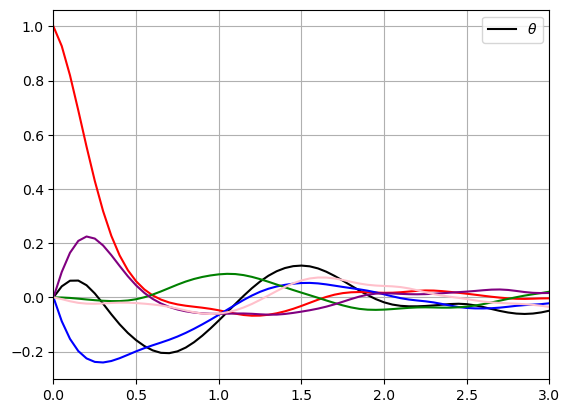

In [57]:
fig , ax = plt.subplots()

# ax.plot(t_resp,response[kick_index-1,:],label="x, where kicked")
# ax.plot(t_resp,response[kick_index-1+1+N,:],label="theta, where kicked")
ax.plot(t_resp,green_function1[kick_index-1+N,:],label="$\\theta$", color = "black")



ax.plot(t_resp,green_function1[kick_index-1,:], color="red")
ax.plot(t_resp,green_function1[kick_index+1,:], color="blue")
ax.plot(t_resp,green_function1[kick_index+2,:], color="green")
ax.plot(t_resp,green_function1[kick_index-2,:], color="purple")
ax.plot(t_resp,green_function1[kick_index,:], color="pink")
ax.set_xlim(0, 3)

ax.legend()
ax.grid()

ax.plot()

[]

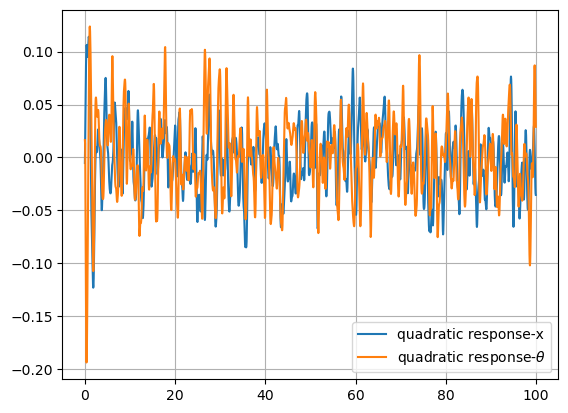

In [58]:
fig , ax = plt.subplots()
ax.plot(t_resp,response1[kick_index+2,:]- phi_mean_0, label = "quadratic response-x")
ax.plot(t_resp,response1[kick_index+1+N,:]- phi_mean_0_z, label = "quadratic response-$\\theta$")

ax.legend()
ax.grid()

ax.plot()

In [59]:
eps2 = 0.7
response2 = 0 
response_m2 = 0 

for i in range(M):
    # Local perturbation: we perturb x in location "kick_index"
    xi_hat = local_F_perturbation(unperturbed_sample_x[i,:],kick_index,eps2)
    zi_hat = unperturbed_sample_z[i,:].copy()
    
    xi_hat_m = local_F_perturbation_minus(unperturbed_sample_x[i,:],kick_index,eps2)

    # Initiate the relaxation run
    state_hat = np.concatenate([xi_hat,zi_hat])
    state_hat_m = np.concatenate([xi_hat_m,zi_hat])

    solution = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, T_resp),
        y0=state_hat,
        t_eval=t_resp,
        method='RK45'
    )
    solution_m = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, T_resp),
        y0=state_hat_m,
        t_eval=t_resp,
        method='RK45'
    )
    
    # Define the observable and take averages: here we choose the full state
    Phi = solution.y
    Phi_m = solution_m.y

    response2 += Phi / M
    response_m2 += Phi_m / M

green_function2 = (response2 - response_m2 )/ (2 * eps2)


[]

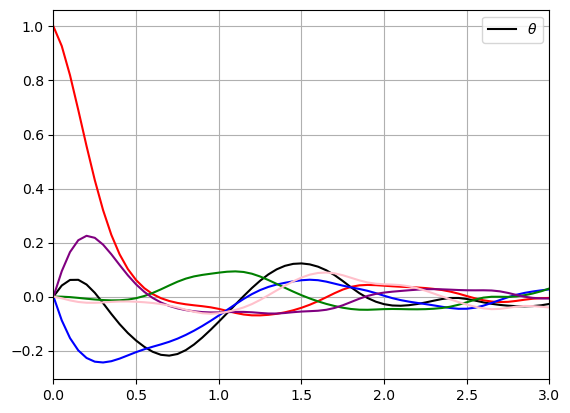

In [61]:
fig , ax = plt.subplots()

# ax.plot(t_resp,response[kick_index-1,:],label="x, where kicked")
# ax.plot(t_resp,response[kick_index-1+1+N,:],label="theta, where kicked")
ax.plot(t_resp,green_function2[kick_index-1+N,:],label="$\\theta$", color = "black")



ax.plot(t_resp,green_function2[kick_index-1,:], color="red")
ax.plot(t_resp,green_function2[kick_index+1,:], color="blue")
ax.plot(t_resp,green_function2[kick_index+2,:], color="green")
ax.plot(t_resp,green_function2[kick_index-2,:], color="purple")
ax.plot(t_resp,green_function2[kick_index,:], color="pink")
ax.set_xlim(0, 3)

ax.legend()
ax.grid()

ax.plot()

[]

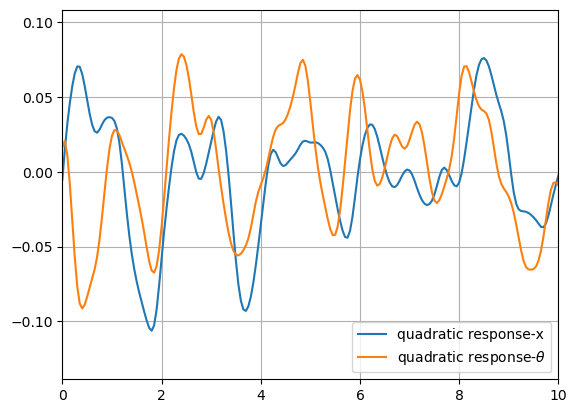

In [64]:
fig , ax = plt.subplots()
ax.plot(t_resp,response2[kick_index+2,:]- phi_mean_0, label = "quadratic response-x")
ax.plot(t_resp,response2[kick_index+1+N,:]- phi_mean_0_z, label = "quadratic response-$\\theta$")
ax.set_xlim(0, 10)

ax.legend()
ax.grid()

ax.plot()

From the quadratic response plot, we can see it randomly oscillates around 0, indicating it’s just noise. So we can say the quadratic response is 0, which corroborates the fact that we seem to be in a linear response regime for our choice of epsilons.

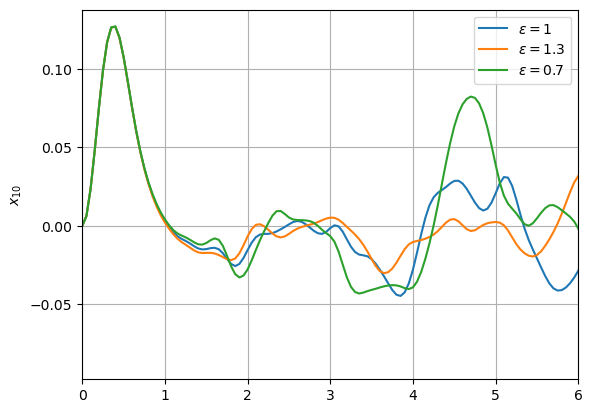

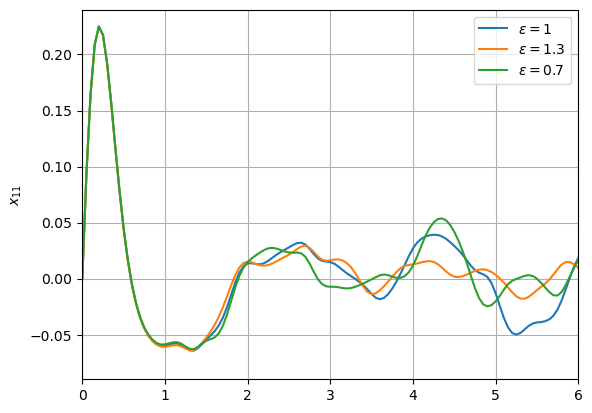

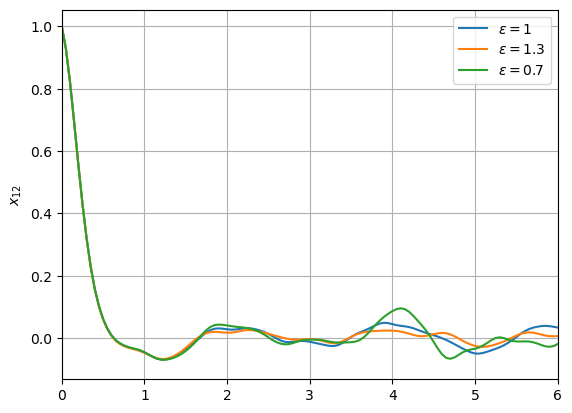

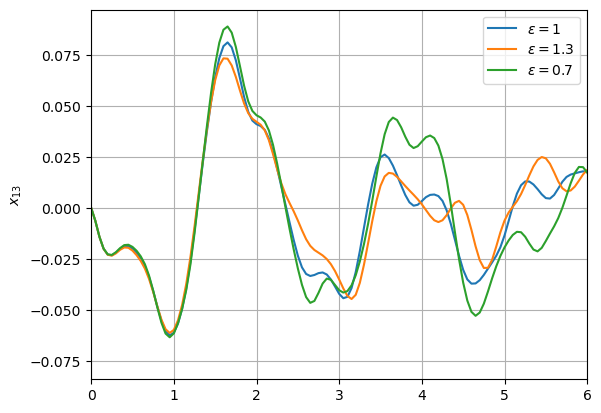

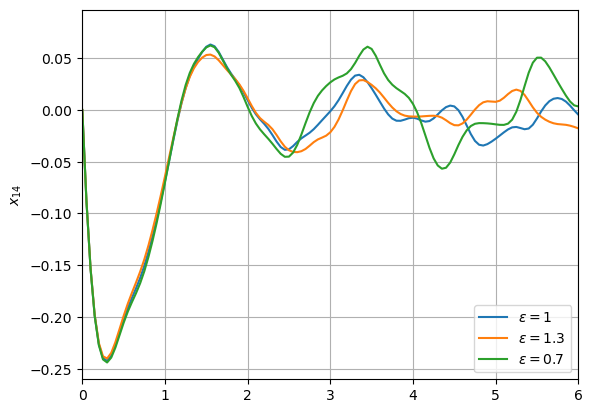

In [66]:
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index-3,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index-3,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index-3,:], label = "$\epsilon = 0.7$")
ax.set_xlim(0, 6)
ax.set_ylabel("$x_{10}$")

ax.legend()
ax.grid()
 
plt.show()

fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index-2,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index-2,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index-2,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$x_{11}$")
ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index-1,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index-1,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index-1,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$x_{12}$")
ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$x_{13}$")
ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index+1,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index+1,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index+1,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$x_{14}$")
ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()



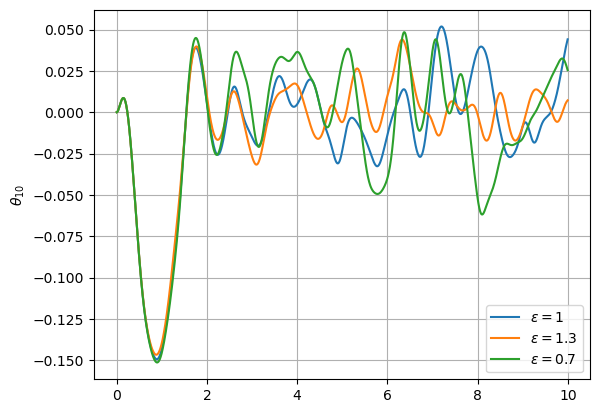

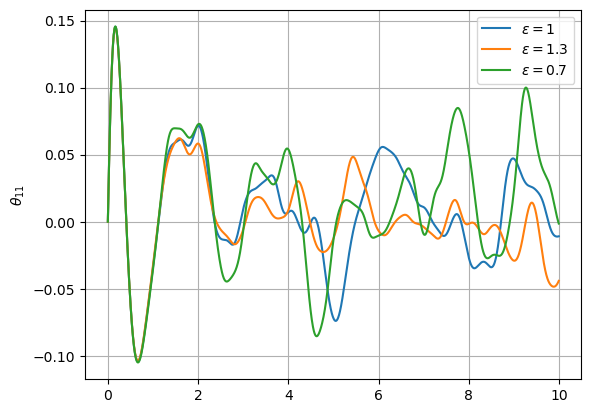

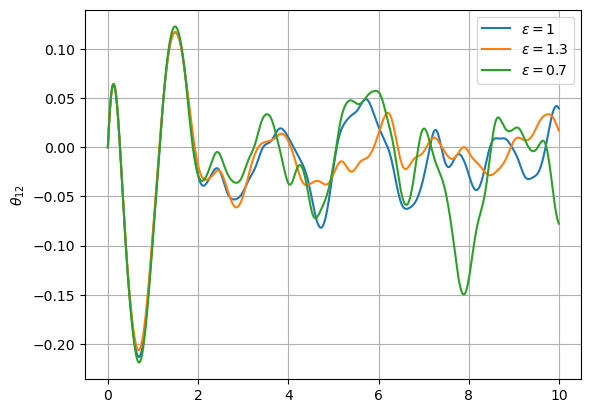

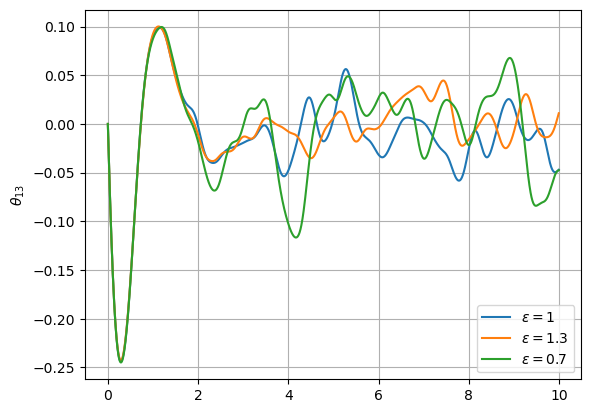

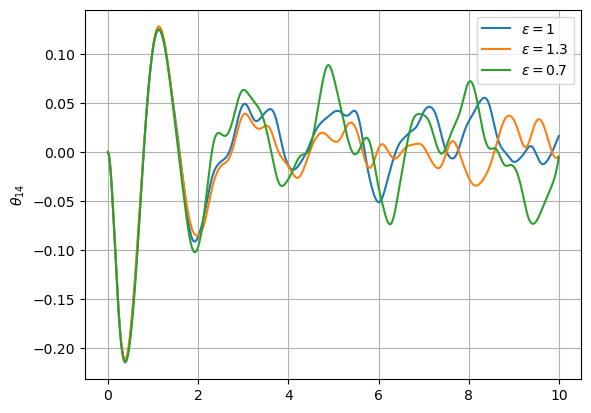

In [49]:
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index-3+N,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index-3+N,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index-3+N,:], label = "$\epsilon = 0.7$")
# ax.set_xlim(0, 6)
ax.set_ylabel("$\\theta_{10}$")

ax.legend()
ax.grid()
 
plt.show()

fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index-2+N,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index-2+N,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index-2+N,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$\\theta_{11}$")
# ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index-1+N,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index-1+N,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index-1+N,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$\\theta_{12}$")
# ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index+N,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index+N,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index+N,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$\\theta_{13}$")
# ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()
fig, ax = plt.subplots()

ax.plot(t_resp, green_function[kick_index+1+N,:], label = "$\epsilon = 1$")
ax.plot(t_resp, green_function1[kick_index+1+N,:], label = "$\epsilon = 1.3$")
ax.plot(t_resp, green_function2[kick_index+1+N,:], label = "$\epsilon = 0.7$")

ax.set_ylabel("$\\theta_{14}$")
# ax.set_xlim(0, 6)

ax.legend()
ax.grid()
 
plt.show()

